# Perbandingan 3 Metode Fuzzy Logic: MAX, Sugeno, dan Mamdani Untuk Penentuan Kalori Harian Berdasarkan Berat Badan dan Aktivitas

Notebook ini membandingkan tiga metode inferensi Fuzzy Logic untuk memprediksi **kebutuhan kalori harian** berdasarkan:
- **Input 1**: Berat Badan (40–120 kg)
- **Input 2**: Aktivitas Fisik (0–10 jam/hari)
- **Output**: Kebutuhan Kalori (1500–3500 kcal)

**Metode yang dibandingkan:**
1. **MAX**: Memilih rule dengan bobot (firing strength) tertinggi
2. **Sugeno (TSK)**: Menggunakan weighted average dari semua rules aktif
3. **Mamdani**: Agregasi fuzzy sets + centroid defuzzification

### 1. Import Library

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

sns.set_style('whitegrid')
print("✓ Library berhasil diimpor!")

✓ Library berhasil diimpor!


### 2. Definisi Fungsi Keanggotaan (Membership Functions)

Pada bagian ini kita definisikan:
- **Fungsi Triangular (trimf)**: untuk representasi fuzzy sets
- **Fungsi Trapezium (trapmf)**: untuk edge cases
- **Aturan Fuzzy (25 Rules)**: kombinasi 5×5 dari linguistic variables

In [87]:
# === FUNGSI KEANGGOTAAN ===
def trimf(x, a, b, c):
    """Triangular membership function."""
    if isinstance(x, (int, float)):
        if x < a or x > c:
            return 0.0
        elif x == b:
            return 1.0
        elif a < x < b:
            return (x - a) / (b - a)
        elif b < x < c:
            return (c - x) / (c - b)
        else:  # x == a or x == c
            return 0.0
    else:
        y = np.zeros_like(x, dtype=float)
        for i, xi in enumerate(x):
            if xi < a or xi > c:
                y[i] = 0.0
            elif xi == b:
                y[i] = 1.0
            elif a < xi < b:
                y[i] = (xi - a) / (b - a)
            elif b < xi < c:
                y[i] = (c - xi) / (c - b)
        return y
    return 0.0

def trapmf(x, a, b, c, d):
    """Trapezoidal membership function."""
    if isinstance(x, (int, float)):
        if x < a or x > d:
            return 0.0
        elif b <= x <= c:
            return 1.0
        elif a <= x < b:
            if b == a:
                return 1.0  # Special case: instant rise
            return (x - a) / (b - a)
        elif c < x <= d:
            if d == c:
                return 1.0  # Special case: instant drop
            return (d - x) / (d - c)
    else:
        y = np.zeros_like(x, dtype=float)
        for i, xi in enumerate(x):
            if xi < a or xi > d:
                y[i] = 0.0
            elif b <= xi <= c:
                y[i] = 1.0
            elif a <= xi < b:
                if b == a:
                    y[i] = 1.0
                else:
                    y[i] = (xi - a) / (b - a)
            elif c < xi <= d:
                if d == c:
                    y[i] = 1.0
                else:
                    y[i] = (d - xi) / (d - c)
        return y
    return 0.0

print("✓ Fungsi keanggotaan didefinisikan")

✓ Fungsi keanggotaan didefinisikan


### 3. Definisi Variabel Linguistik & Rule Base

In [77]:
# === FUZZIFIKASI INPUT BERAT BADAN ===
def fuzzifikasi_berat(berat):
    return {
        'Sangat Ringan': trapmf(berat, 40, 40, 55, 70),
        'Ringan':        trimf(berat, 55, 70, 85),
        'Sedang':        trimf(berat, 70, 85, 100),
        'Tinggi':        trimf(berat, 85, 100, 115),
        'Sangat Tinggi': trapmf(berat, 100, 115, 121, 121),
    }

# === FUZZIFIKASI INPUT AKTIVITAS FISIK ===
def fuzzifikasi_aktivitas(aktivitas):
    return {
        'Sangat Rendah': trapmf(aktivitas, 0, 0, 1.5, 3),
        'Rendah':        trimf(aktivitas, 1.5, 3, 5),
        'Sedang':        trimf(aktivitas, 3, 5, 7),
        'Tinggi':        trimf(aktivitas, 5, 7, 8.5),
        'Sangat Tinggi': trapmf(aktivitas, 7, 8.5, 10.1, 10.1),
    }

### 4. Metode 1: MAMDANI

Metode Mamdani menggunakan agregasi fuzzy sets dan defuzzifikasi dengan metode centroid.

In [78]:
def inferensi_mamdani(berat_input, aktivitas_input):
    """Mamdani inference with centroid defuzzification."""
    mu_berat = fuzzifikasi_berat(berat_input)
    mu_aktivitas = fuzzifikasi_aktivitas(aktivitas_input)
    
    # Agregasi: tentukan bobot maksimal untuk setiap level kalori
    aggregated_mu = {level: 0 for level in kalori_levels}
    active_rules = []
    
    for (b_level, a_level, k_level) in RULES:
        w = min(mu_berat[b_level], mu_aktivitas[a_level])
        if w > 0:
            active_rules.append((w, b_level, a_level, k_level))
            aggregated_mu[k_level] = max(aggregated_mu[k_level], w)
    
    # Centroid defuzzification
    k_domain = np.linspace(1500, 3500, 500)
    numerator = 0
    denominator = 0
    
    for k in k_domain:
        mu_aggregated = 0
        for level, w_agg in aggregated_mu.items():
            mu_clipped = min(mf_kalori(k, level), w_agg)
            mu_aggregated = max(mu_aggregated, mu_clipped)
        numerator += k * mu_aggregated
        denominator += mu_aggregated
    
    result = numerator / denominator if denominator > 0 else 2500
    best_rule = active_rules[0] if active_rules else (0, 'N/A', 'N/A', 'Sedang')
    
    return result, best_rule, active_rules

print("✓ Fungsi Mamdani siap digunakan")

✓ Fungsi Mamdani siap digunakan


#### 4a. Test Mamdani dengan Input Custom

**Input nilai `berat_test` dan `aktivitas_test` untuk melihat hasil prediksi kalori**

In [ ]:
# === TEST MAMDANI ===
print("\n" + "="*60)
print("INPUT UNTUK METODE MAMDANI")
print("="*60)
berat_test = float(input("Masukkan berat badan (kg, 40-120): "))
aktivitas_test = float(input("Masukkan aktivitas fisik (jam/hari, 0-10): "))
print("="*60)

hasil_mamdani, best_rule_mamdani, active_mamdani = inferensi_mamdani(berat_test, aktivitas_test)

print("="*60)
print(f"HASIL METODE MAMDANI")
print("="*60)
print(f"Input: Berat Badan = {berat_test} kg, Aktivitas = {aktivitas_test} jam/hari")
print(f"\n Output Kalori: {hasil_mamdani:.2f} kcal")
print(f"\n Rule Paling Dominan: {best_rule_mamdani[1]} & {best_rule_mamdani[2]} → {best_rule_mamdani[3]}")
print(f"   Bobot (firing strength): {best_rule_mamdani[0]:.4f}")
if len(active_mamdani) <= 5:
    print(f"\n Semua Rules Aktif:")
    for w, b_level, a_level, k_level in active_mamdani:
        print(f"    {b_level} & {a_level} → {k_level} (w={w:.4f})")
print("="*60)


INPUT UNTUK METODE MAMDANI
HASIL METODE MAMDANI
Input: Berat Badan = 120.0 kg, Aktivitas = 10.0 jam/hari

✅ Output Kalori: 3267.70 kcal

📌 Rule Paling Dominan: Sangat Tinggi & Sangat Tinggi → Sangat Tinggi
   Bobot (firing strength): 1.0000

📋 Semua Rules Aktif:
   • Sangat Tinggi & Sangat Tinggi → Sangat Tinggi (w=1.0000)


### 5. Metode 2: SUGENO (TSK)

Metode Sugeno menggunakan weighted average dari output setiap rule yang aktif.

In [80]:
def inferensi_sugeno(berat_input, aktivitas_input):
    """Sugeno (TSK) inference with weighted average."""
    mu_berat = fuzzifikasi_berat(berat_input)
    mu_aktivitas = fuzzifikasi_aktivitas(aktivitas_input)
    
    numerator = 0
    denominator = 0
    active_rules = []
    
    for (b_level, a_level, k_level) in RULES:
        w = min(mu_berat[b_level], mu_aktivitas[a_level])
        if w > 0:
            z = SINGLETONS[k_level]
            numerator += w * z
            denominator += w
            active_rules.append((w, b_level, a_level, k_level))
    
    result = numerator / denominator if denominator > 0 else 2500
    best_rule = active_rules[0] if active_rules else (0, 'N/A', 'N/A', 'Sedang')
    active_rules.sort(key=lambda x: -x[0])  # Sort by weight descending
    
    return result, best_rule, active_rules

print("✓ Fungsi Sugeno siap digunakan")

✓ Fungsi Sugeno siap digunakan


#### 5a. Test Sugeno dengan Input Custom

In [ ]:
# === TEST SUGENO ===
# Menggunakan input dari MAMDANI (berat_test & aktivitas_test sudah di-define)
hasil_sugeno, best_rule_sugeno, active_sugeno = inferensi_sugeno(berat_test, aktivitas_test)

print("="*60)
print(f"HASIL METODE SUGENO (TSK)")
print("="*60)
print(f"Input: Berat Badan = {berat_test} kg, Aktivitas = {aktivitas_test} jam/hari")
print(f"\n Output Kalori: {hasil_sugeno:.2f} kcal")
print(f"\n Rule Paling Dominan: {best_rule_sugeno[1]} & {best_rule_sugeno[2]} → {best_rule_sugeno[3]}")
print(f"   Bobot (firing strength): {best_rule_sugeno[0]:.4f}")
if len(active_sugeno) <= 5:
    print(f"\n Top 5 Rules Aktif (sorted by weight):")
    for i, (w, b_level, a_level, k_level) in enumerate(active_sugeno[:5], 1):
        print(f"   {i}. {b_level} & {a_level} → {k_level} (w={w:.4f})")
print("="*60)

HASIL METODE SUGENO (TSK)
Input: Berat Badan = 120.0 kg, Aktivitas = 10.0 jam/hari

✅ Output Kalori: 3200.00 kcal

📌 Rule Paling Dominan: Sangat Tinggi & Sangat Tinggi → Sangat Tinggi
   Bobot (firing strength): 1.0000

📋 Top 5 Rules Aktif (sorted by weight):
   1. Sangat Tinggi & Sangat Tinggi → Sangat Tinggi (w=1.0000)


### 6. Metode 3: MAX

Metode MAX memilih rule dengan bobot tertinggi (winner-takes-all).

In [82]:
def inferensi_max(berat_input, aktivitas_input):
    """MAX inference (winner-takes-all)."""
    mu_berat = fuzzifikasi_berat(berat_input)
    mu_aktivitas = fuzzifikasi_aktivitas(aktivitas_input)
    
    max_weight = 0
    best_output = None
    best_rule = None
    active_rules = []
    
    for (b_level, a_level, k_level) in RULES:
        w = min(mu_berat[b_level], mu_aktivitas[a_level])
        if w > 0:
            active_rules.append((w, b_level, a_level, k_level))
            if w > max_weight:
                max_weight = w
                best_output = SINGLETONS[k_level]
                best_rule = (w, b_level, a_level, k_level)
    
    active_rules.sort(key=lambda x: -x[0])  # Sort by weight descending
    
    return best_output if best_output else 2500, best_rule, active_rules

print("✓ Fungsi MAX siap digunakan")

✓ Fungsi MAX siap digunakan


#### 6a. Test MAX dengan Input Custom

In [ ]:
# === TEST MAX ===
# Menggunakan input dari MAMDANI (berat_test & aktivitas_test sudah di-define)
hasil_max, best_rule_max, active_max = inferensi_max(berat_test, aktivitas_test)

print("="*60)
print(f"HASIL METODE MAX")
print("="*60)
print(f"Input: Berat Badan = {berat_test} kg, Aktivitas = {aktivitas_test} jam/hari")
print(f"\n Output Kalori: {hasil_max:.2f} kcal")
if best_rule_max is not None:
    print(f"\n Rule Paling Dominan (Winner): {best_rule_max[1]} & {best_rule_max[2]} → {best_rule_max[3]}")
    print(f"   Bobot (firing strength): {best_rule_max[0]:.4f}")
else:
    print(f"\n Rule Paling Dominan: TIDAK ADA (input di luar range)")
if len(active_max) > 0 and len(active_max) <= 5:
    print(f"\n Top 5 Rules Aktif (sorted by weight):")
    for i, (w, b_level, a_level, k_level) in enumerate(active_max[:5], 1):
        print(f"   {i}. {b_level} & {a_level} → {k_level} (w={w:.4f})")
print("="*60)

HASIL METODE MAX
Input: Berat Badan = 120.0 kg, Aktivitas = 10.0 jam/hari

✅ Output Kalori: 3200.00 kcal

📌 Rule Paling Dominan (Winner): Sangat Tinggi & Sangat Tinggi → Sangat Tinggi
   Bobot (firing strength): 1.0000

📋 Top 5 Rules Aktif (sorted by weight):
   1. Sangat Tinggi & Sangat Tinggi → Sangat Tinggi (w=1.0000)


### 7. Perbandingan Ketiga Metode pada Input yang Sama

In [84]:
print("\n" + "="*70)
print(f"PERBANDINGAN KETIGA METODE")
print("="*70)
print(f"Input: Berat Badan = {berat_test} kg | Aktivitas = {aktivitas_test} jam/hari")
print("-"*70)
print(f"Metode MAX    : {hasil_max:>8.2f} kcal")
print(f"Metode Sugeno : {hasil_sugeno:>8.2f} kcal")
print(f"Metode Mamdani: {hasil_mamdani:>8.2f} kcal")
print("-"*70)
perbedaan_max_sugeno = abs(hasil_max - hasil_sugeno)
perbedaan_max_mamdani = abs(hasil_max - hasil_mamdani)
perbedaan_sugeno_mamdani = abs(hasil_sugeno - hasil_mamdani)
print(f"Selisih MAX vs Sugeno   : {perbedaan_max_sugeno:.2f} kcal")
print(f"Selisih MAX vs Mamdani  : {perbedaan_max_mamdani:.2f} kcal")
print(f"Selisih Sugeno vs Mamdani: {perbedaan_sugeno_mamdani:.2f} kcal")
print("="*70)


PERBANDINGAN KETIGA METODE
Input: Berat Badan = 120.0 kg | Aktivitas = 10.0 jam/hari
----------------------------------------------------------------------
Metode MAX    :  3200.00 kcal
Metode Sugeno :  3200.00 kcal
Metode Mamdani:  3267.70 kcal
----------------------------------------------------------------------
Selisih MAX vs Sugeno   : 0.00 kcal
Selisih MAX vs Mamdani  : 67.70 kcal
Selisih Sugeno vs Mamdani: 67.70 kcal


### 8. Auto-Generate Test Cases

Bagian ini akan otomatis menghasilkan test cases dan menampilkan tabel perbandingan ketiga metode.

In [85]:
# Define test cases
test_cases = [
    ("TC1", 50, 1),    # Berat ringan, aktivitas sangat rendah
    ("TC2", 65, 3),    # Berat sedang-ringan, aktivitas rendah-sedang
    ("TC3", 80, 5),    # Berat sedang-tinggi, aktivitas sedang
    ("TC4", 100, 2),   # Berat tinggi, aktivitas rendah
    ("TC5", 60, 7),    # Berat sedang, aktivitas tinggi
    ("TC6", 110, 9),   # Berat sangat tinggi, aktivitas sangat tinggi
]

results = []
for tc_name, berat, aktivitas in test_cases:
    res_max, rule_max, _ = inferensi_max(berat, aktivitas)
    res_sugeno, rule_sugeno, _ = inferensi_sugeno(berat, aktivitas)
    res_mamdani, rule_mamdani, _ = inferensi_mamdani(berat, aktivitas)
    
    results.append({
        'Test Case': tc_name,
        'Berat Badan (kg)': berat,
        'Aktivitas (jam/hari)': aktivitas,
        'Metode MAX (kcal)': round(res_max, 2),
        'Metode Sugeno (kcal)': round(res_sugeno, 2),
        'Metode Mamdani (kcal)': round(res_mamdani, 2),
        'Rule Dominan': f"{rule_max[1]} & {rule_max[2]} → {rule_max[3]}"
    })

df_results = pd.DataFrame(results)

print("\n" + "="*120)
print("TABEL PERBANDINGAN AUTO-GENERATED TEST CASES")
print("="*120)
print(df_results.to_string(index=False))
print("="*120)


TABEL PERBANDINGAN AUTO-GENERATED TEST CASES
Test Case  Berat Badan (kg)  Aktivitas (jam/hari)  Metode MAX (kcal)  Metode Sugeno (kcal)  Metode Mamdani (kcal)                                  Rule Dominan
      TC1                50                     1               1800               1800.00                1732.30 Sangat Ringan & Sangat Rendah → Sangat Rendah
      TC2                65                     3               2100               2000.00                2009.88                      Ringan & Rendah → Rendah
      TC3                80                     5               2500               2366.67                2387.69                      Sedang & Sedang → Sedang
      TC4               100                     2               2100               2233.33                2285.28               Tinggi & Sangat Rendah → Rendah
      TC5                60                     7               2100               2233.33                2285.28               Sangat Ringan & Tinggi → R

### 9. Visualisasi Membership Functions

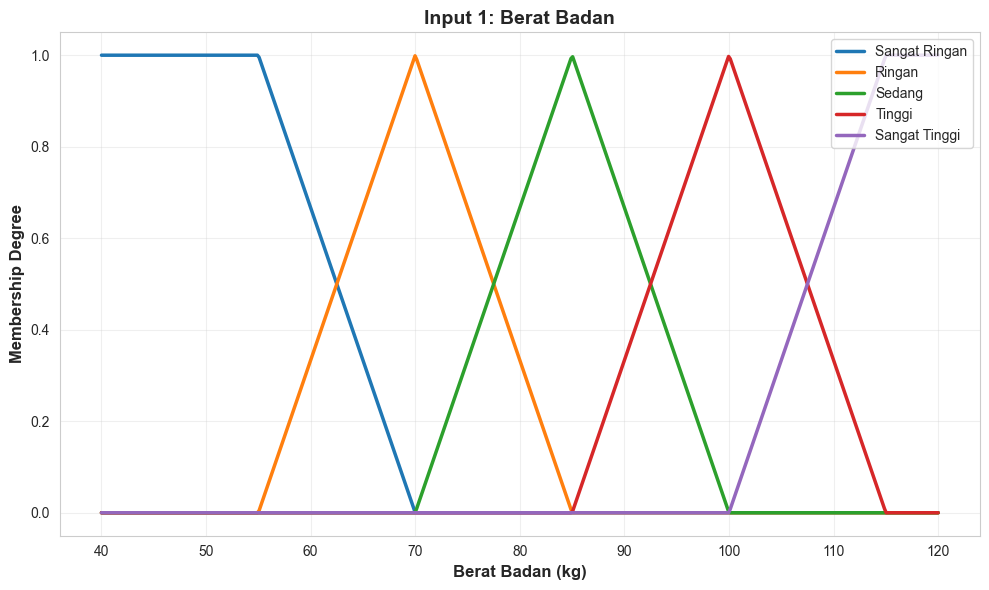

✓ Visualisasi Membership Function: Berat Badan ditampilkan


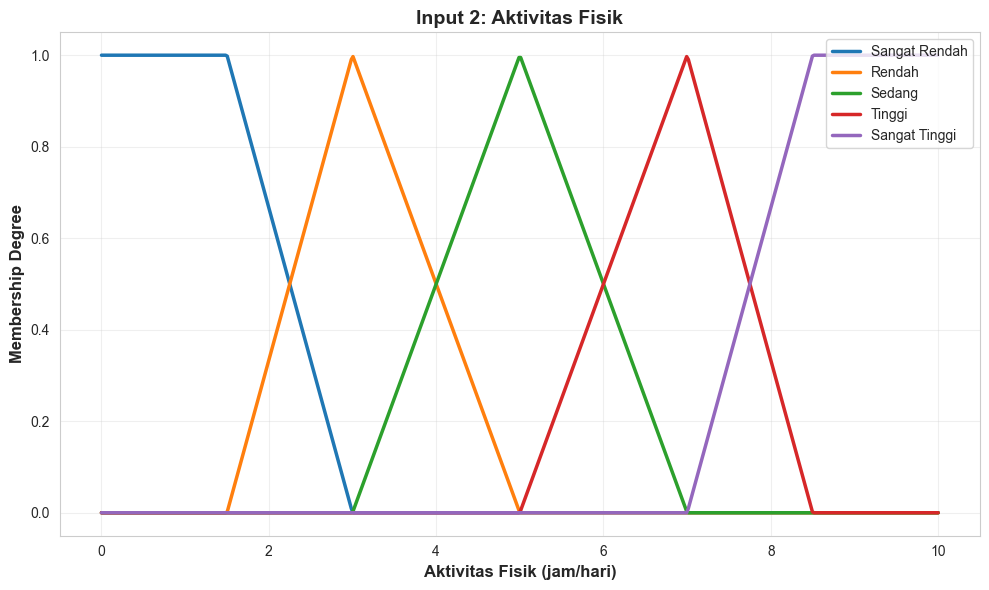

✓ Visualisasi Membership Function: Aktivitas Fisik ditampilkan


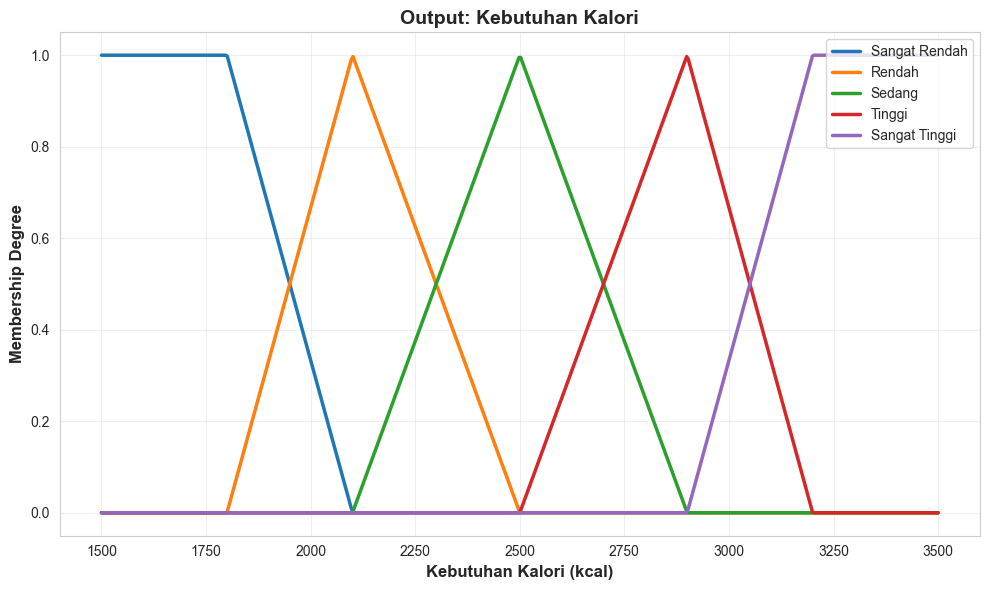

✓ Visualisasi Membership Function: Kebutuhan Kalori ditampilkan


In [88]:
# === VISUALISASI MEMBERSHIP FUNCTIONS ===

# Figure 1: Berat Badan
fig1, ax1 = plt.subplots(figsize=(10, 6))
x_berat = np.linspace(40, 120, 500)
for level in berat_levels:
    if level == 'Sangat Ringan':
        mf = trapmf(x_berat, 40, 40, 55, 70)
    elif level == 'Ringan':
        mf = trimf(x_berat, 55, 70, 85)
    elif level == 'Sedang':
        mf = trimf(x_berat, 70, 85, 100)
    elif level == 'Tinggi':
        mf = trimf(x_berat, 85, 100, 115)
    else:  # Sangat Tinggi
        mf = trapmf(x_berat, 100, 115, 121, 121)
    ax1.plot(x_berat, mf, label=level, linewidth=2.5)

ax1.set_xlabel('Berat Badan (kg)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Membership Degree', fontsize=12, fontweight='bold')
ax1.set_title('Input 1: Berat Badan', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
fig1.tight_layout()
plt.show()
print("✓ Visualisasi Membership Function: Berat Badan ditampilkan")

# Figure 2: Aktivitas Fisik
fig2, ax2 = plt.subplots(figsize=(10, 6))
x_aktivitas = np.linspace(0, 10, 500)
for level in aktivitas_levels:
    if level == 'Sangat Rendah':
        mf = trapmf(x_aktivitas, 0, 0, 1.5, 3)
    elif level == 'Rendah':
        mf = trimf(x_aktivitas, 1.5, 3, 5)
    elif level == 'Sedang':
        mf = trimf(x_aktivitas, 3, 5, 7)
    elif level == 'Tinggi':
        mf = trimf(x_aktivitas, 5, 7, 8.5)
    else:  # Sangat Tinggi
        mf = trapmf(x_aktivitas, 7, 8.5, 10.1, 10.1)
    ax2.plot(x_aktivitas, mf, label=level, linewidth=2.5)

ax2.set_xlabel('Aktivitas Fisik (jam/hari)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Membership Degree', fontsize=12, fontweight='bold')
ax2.set_title('Input 2: Aktivitas Fisik', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
plt.show()
print("✓ Visualisasi Membership Function: Aktivitas Fisik ditampilkan")

# Figure 3: Kebutuhan Kalori
fig3, ax3 = plt.subplots(figsize=(10, 6))
x_kalori = np.linspace(1500, 3500, 500)
for level in kalori_levels:
    if level == 'Sangat Rendah':
        mf = trapmf(x_kalori, 1500, 1500, 1800, 2100)
    elif level == 'Rendah':
        mf = trimf(x_kalori, 1800, 2100, 2500)
    elif level == 'Sedang':
        mf = trimf(x_kalori, 2100, 2500, 2900)
    elif level == 'Tinggi':
        mf = trimf(x_kalori, 2500, 2900, 3200)
    else:  # Sangat Tinggi
        mf = trapmf(x_kalori, 2900, 3200, 3500, 3500)
    ax3.plot(x_kalori, mf, label=level, linewidth=2.5)

ax3.set_xlabel('Kebutuhan Kalori (kcal)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Membership Degree', fontsize=12, fontweight='bold')
ax3.set_title('Output: Kebutuhan Kalori', fontsize=14, fontweight='bold')
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, alpha=0.3)
fig3.tight_layout()
plt.show()
print("✓ Visualisasi Membership Function: Kebutuhan Kalori ditampilkan")